In [3]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define transformations (Convert to tensor and normalize pixel values between -1 and 1)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Download and load the datasets
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Create DataLoaders to handle batching and shuffling
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Quick sanity check
images, labels = next(iter(train_loader))
print(f"Batch image shape: {labels}")  # Expected: [64, 3, 32, 32] (Batch, Channels, Height, Width)'''

100%|██████████| 170M/170M [30:13<00:00, 94.0kB/s]


Batch image shape: tensor([3, 7, 2, 7, 3, 9, 4, 8, 0, 3, 1, 0, 7, 3, 8, 2, 6, 5, 8, 5, 5, 6, 7, 5,
        0, 1, 9, 0, 4, 4, 8, 6, 3, 9, 3, 0, 1, 3, 3, 2, 1, 7, 9, 4, 8, 7, 0, 3,
        7, 7, 0, 8, 3, 7, 9, 2, 0, 6, 7, 7, 7, 9, 0, 0])



DEFINE THE Residual Network
MODEL

# REBUILDING THE PROJECT


In [4]:
import numpy as np
import pandas as pd
import os
import random

import torch
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from torch.utils.data.dataloader import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import pickle
import matplotlib.pyplot as plt

from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR


seeding and setting device

In [26]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#CONFIG FOR MY BASE PROJECT-----------------
config = {"device" : device,"learning_rate" :0.001,"epochs" : 20, "label_smoothing":0}
#-------------------------------------------

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
seed_everything()

print(f"Using device: {device}")


Using device: cuda


In [6]:
# hyperparams

config = {"device" : device,"learning_rate" :0.001,"epochs" : 50, "label_smoothing":0}


importing the data

OneHot encoding the Ydata

Defining and Loading a dataloader class

In [7]:
from torch.utils.data.dataloader import DataLoader
# making a torch.Dataset object that we will need to feed into DataLoader
class data_loader(torch.utils.data.Dataset):
  def __init__(self, x_tensor, y_tensor):
    self.x= x_tensor
    self.y= y_tensor

  def __len__(self):
    return len(self.x)

  def __getitem__(self, idx):
    return self.x[idx], self.y[idx]



In [8]:
def get_dataloader(x_train,y_train,x_test,y_test):
  '''
  this function returns the high level train_loader, test_loader and val_loader
  objects
  it takes in the preprocessed train, test data in the form of tensors.
  '''
  train_data= data_loader(x_train, y_train)
  test_data = data_loader(x_test, y_test)

  train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
  test_loader = DataLoader(test_data, batch_size=64, shuffle=False)
  return train_loader, test_loader

 BASELINE NEURAL NETWORK CLASS

In [9]:
from torch import nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
        )

        # projection shortcut — only built when dimensions actually change
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
            nn.BatchNorm2d(out_channels),
        ) if (in_channels != out_channels or stride != 1) else nn.Identity()

    def forward(self, x):
        return F.relu(self.block(x) + self.shortcut(x))


class ResidualChain(nn.Module):
    def __init__(self, num_blocks, in_channels, out_channels):
        super().__init__()
        self.blocks = nn.Sequential(*[
            ResidualBlock(in_channels if i == 0 else out_channels, out_channels, 2 if i == 0 else 1)
            for i in range(num_blocks)
        ])

    def forward(self, x):
      return self.blocks(x)

class residual_CNN(nn.Module):
  def __init__(self, input_size, num_of_classes):
    super().__init__()
    self.stem = nn.Sequential(
        nn.Conv2d(input_size, 32, kernel_size=3, stride=1, padding=1, bias=False),
        nn.BatchNorm2d(32),
        nn.ReLU(inplace=True)
    )

    self.network = nn.Sequential(
        ResidualChain(2, 32, 64),    # stage 1: 32 -> 64
        ResidualChain(2, 64, 128),   # stage 2: 64 -> 128
        ResidualChain(2, 128, 256),  # stage 3: 128 -> 256
    )

    self.gap = nn.AdaptiveAvgPool2d((1, 1))
    self.classifier = nn.Linear(256, num_of_classes)

  def forward(self, x):
    x = self.stem(x)
    x = self.network(x)
    x = self.gap(x)              # GAP happens BEFORE the classifier
    x = torch.flatten(x, 1)
    return self.classifier(x)

In [10]:
def build_model(model_type, config):
  '''
  creates an instance of given model class blueprint and moves it to the device.
  '''
  model = model_type(3, 10)
  model.to(config["device"])

  return model

In [11]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
  '''
  returns the metrics coming from this epoch. returns train_metrics(dict):
  {train_loss:, train_accuracy:}

  '''
  model.train()
  # sets the evaluation parameters to zero first
  total_epoch_loss = 0
  training_correct = 0
  training_total = 0
  for batch_features, batch_labels in train_loader:
    # Move batch_features and batch_labels to the correct device
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    optimizer.zero_grad()
    outputs= model(batch_features)
    loss= criterion(outputs, batch_labels)
    total_epoch_loss += loss.item()
    loss.backward()
    optimizer.step()
    _, predicted =torch.max(outputs, 1)
    training_correct+=(predicted==batch_labels).sum().item()
    training_total += batch_labels.shape[0]
  average_loss= total_epoch_loss/len(train_loader)
  training_metrics = {'train_loss': average_loss, 'train_accuracy': training_correct/training_total}
  return training_metrics

In [16]:
def test_one_epoch(model, test_loader, device, num_classes=10, nbins=20, lossfn=nn.CrossEntropyLoss()):
  """
  runs tests on the model and returns the accuracy, ece, loss, and confusion matrix
  """
  model.eval()
  total = 0
  total_loss = 0
  bin_total = torch.zeros(nbins, device=device)
  bin_aggregate = torch.zeros(nbins, device=device)
  correct = torch.zeros(nbins, device=device)
  bin_edges = torch.linspace(0, 1, nbins + 1).to(device)

  # confusion matrix accumulator: rows = true label, cols = predicted label
  confusion_matrix = torch.zeros(num_classes, num_classes, dtype=torch.long, device=device)

  with torch.no_grad():
    for batch_features, batch_labels in test_loader:
      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
      output = model(batch_features)
      probabilities = torch.softmax(output, dim=1)
      confidence, predicted = torch.max(probabilities, 1)
      loss = lossfn(output, batch_labels)
      total_loss += loss.item()

      is_correct = (predicted == batch_labels)

      bin_indices = torch.bucketize(confidence, bin_edges[1:-1])
      for b in range(nbins):
        mask = (bin_indices == b)
        bin_aggregate[b] += confidence[mask].sum()
        bin_total[b] += mask.sum()
        correct[b] += is_correct[mask].sum()
      total += batch_labels.shape[0]

      # --- confusion matrix update ---
      indices = batch_labels * num_classes + predicted
      binned = torch.bincount(indices, minlength=num_classes * num_classes)
      confusion_matrix += binned.reshape(num_classes, num_classes)

  emperical = torch.zeros(nbins, device=device)
  for b in range(nbins):
    emperical[b] = correct[b] / bin_total[b]
  loss_avg = total_loss / len(test_loader)
  average = bin_aggregate.div(bin_total)
  non_empty = bin_total > 0
  average = average[non_empty]
  emperical = emperical[non_empty]
  bin_total = bin_total[non_empty]
  ece = ((bin_total) / bin_total.sum() * (average - emperical).abs()).sum()
  accuracy = correct.sum() / total

  return accuracy, ece, loss_avg, confusion_matrix

In [23]:
def run_model(model, config, train_loader, test_loader, schedule= False):
  """
  complete main loop
  """
  model = build_model(model, config)
  lossfn = nn.CrossEntropyLoss(label_smoothing= config["label_smoothing"])
  optimizer = optim.Adam(model.parameters(), lr=config["learning_rate"])
  if schedule:
    warmup = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=5)
    cosine = CosineAnnealingLR(optimizer, T_max=45, eta_min=1e-5)
    scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[5])
  history = {"training_loss": [], "validation_accuracy" : [], "training_accuracy":[], "ece":[], "validation_loss":[]}
  training_epoch_losses = []
  validation_accuracy =[]
  training_accuracy = []

  for epoch in range(config["epochs"]):
    print(epoch, "out of ", config["epochs"])
    epoch_metrics = train_one_epoch(model, train_loader, lossfn, optimizer, device)
    history["training_loss"].append(epoch_metrics['train_loss'])
    history["training_accuracy"].append(epoch_metrics['train_accuracy'])
    accuracy, ece, validation_loss, confusion_matrix= test_one_epoch(model, test_loader, device)
    history["validation_loss"].append(validation_loss)
    history["validation_accuracy"].append(accuracy.cpu())
    history["ece"].append(ece)
    history["confusion_matrix"]=confusion_matrix
    print(history["validation_accuracy"][-1].item())

  return history, model

In [24]:
def display_metrics(metrics):
  """
  takes in metrics and outputs a plot of the metrics
  """
  epochs = range(1, len(metrics["training_loss"]) + 1)

  fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))
  fig.suptitle("Training metrics", fontsize=13, fontweight="medium")

  # loss
  ax_loss.plot(epochs, metrics["training_loss"], label="train loss")
  ax_loss.plot(epochs, metrics["validation_loss"],   label="val loss", linestyle="--")
  ax_loss.set(title="Loss", xlabel="epoch", ylabel="loss")
  ax_loss.legend()

  # accuracy
  # Convert validation_accuracy tensors to CPU and then to numpy for plotting
  val_accuracy_cpu = [acc.cpu().numpy() for acc in metrics["validation_accuracy"]]
  ax_acc.plot(epochs, metrics["training_accuracy"], label="train acc")
  ax_acc.plot(epochs, val_accuracy_cpu,   label="val acc", linestyle="--")
  ax_acc.set(title="Accuracy", xlabel="epoch", ylabel="accuracy", ylim=(0, 1))
  ax_acc.legend()


  plt.tight_layout()
  plt.show()

In [27]:
metrics, model = run_model(residual_CNN, config, train_loader, test_loader)

0 out of  20
0.6710000038146973
1 out of  20
0.7404999732971191
2 out of  20
0.7709999680519104
3 out of  20
0.7889999747276306
4 out of  20
0.7955999970436096
5 out of  20
0.7973999977111816
6 out of  20
0.8050000071525574
7 out of  20
0.8143999576568604
8 out of  20
0.8145999908447266
9 out of  20
0.8251000046730042
10 out of  20
0.8163999915122986
11 out of  20
0.8202999830245972
12 out of  20
0.8104000091552734
13 out of  20
0.8161999583244324
14 out of  20
0.8129000067710876
15 out of  20
0.8155999779701233
16 out of  20
0.81659996509552
17 out of  20
0.8285999894142151
18 out of  20
0.8234999775886536
19 out of  20
0.8199999928474426


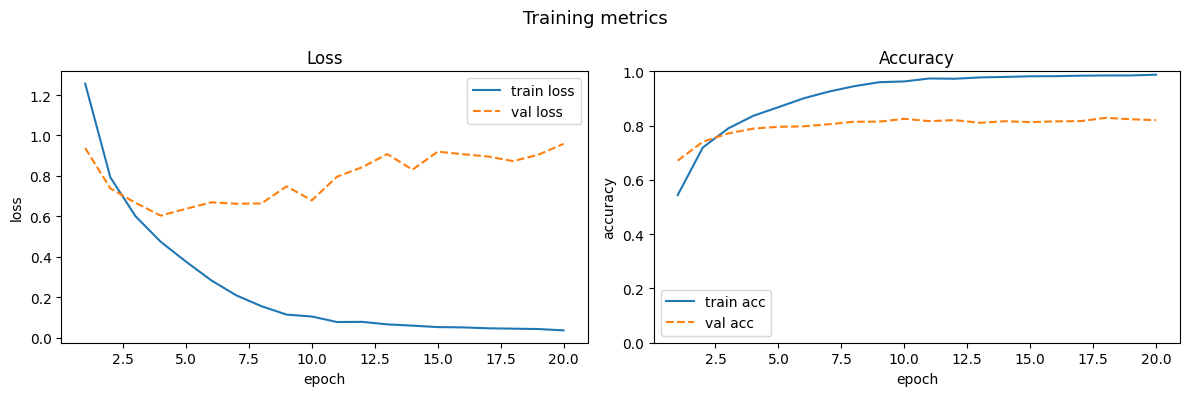

In [28]:
display_metrics(metrics)

In [29]:
def classification_report_from_cm(cm, class_names=None):
    """
    Computes per-class precision, recall, F1, and support directly from
    a confusion matrix (rows = true label, cols = predicted label),
    and prints a classification-report-style table.
    """
    cm = cm.cpu().float() if torch.is_tensor(cm) else torch.tensor(cm, dtype=torch.float32)
    num_classes = cm.shape[0]

    if class_names is None:
        class_names = [str(i) for i in range(num_classes)]

    support = cm.sum(dim=1)                  # true instances per class (row sums)
    predicted_totals = cm.sum(dim=0)          # predicted instances per class (col sums)
    true_positives = cm.diag()                # correct predictions per class

    # avoid div-by-zero: where denom is 0, set metric to 0
    precision = torch.where(predicted_totals > 0, true_positives / predicted_totals, torch.zeros_like(true_positives))
    recall = torch.where(support > 0, true_positives / support, torch.zeros_like(true_positives))
    f1 = torch.where((precision + recall) > 0, 2 * precision * recall / (precision + recall), torch.zeros_like(precision))

    total_support = support.sum()
    accuracy = true_positives.sum() / total_support

    macro_precision = precision.mean()
    macro_recall = recall.mean()
    macro_f1 = f1.mean()

    weighted_precision = (precision * support).sum() / total_support
    weighted_recall = (recall * support).sum() / total_support
    weighted_f1 = (f1 * support).sum() / total_support

    # --- print formatted table ---
    header = f"{'':<15}{'precision':>10}{'recall':>10}{'f1-score':>10}{'support':>10}"
    print(header)
    print()
    for i, name in enumerate(class_names):
        print(f"{name:<15}{precision[i]:>10.2f}{recall[i]:>10.2f}{f1[i]:>10.2f}{int(support[i]):>10}")
    print()
    print(f"{'accuracy':<15}{'':>10}{'':>10}{accuracy:>10.2f}{int(total_support):>10}")
    print(f"{'macro avg':<15}{macro_precision:>10.2f}{macro_recall:>10.2f}{macro_f1:>10.2f}{int(total_support):>10}")
    print(f"{'weighted avg':<15}{weighted_precision:>10.2f}{weighted_recall:>10.2f}{weighted_f1:>10.2f}{int(total_support):>10}")

    return {
        "precision": precision, "recall": recall, "f1": f1, "support": support,
        "accuracy": accuracy.item(),
        "macro_avg": {"precision": macro_precision.item(), "recall": macro_recall.item(), "f1": macro_f1.item()},
        "weighted_avg": {"precision": weighted_precision.item(), "recall": weighted_recall.item(), "f1": weighted_f1.item()},
    }

In [30]:
classification_report_from_cm(metrics["confusion_matrix"])

                precision    recall  f1-score   support

0                    0.86      0.81      0.84      1000
1                    0.89      0.92      0.91      1000
2                    0.66      0.84      0.74      1000
3                    0.71      0.62      0.67      1000
4                    0.79      0.79      0.79      1000
5                    0.79      0.71      0.75      1000
6                    0.84      0.89      0.86      1000
7                    0.86      0.87      0.86      1000
8                    0.91      0.88      0.89      1000
9                    0.90      0.88      0.89      1000

accuracy                                 0.82     10000
macro avg            0.82      0.82      0.82     10000
weighted avg         0.82      0.82      0.82     10000


{'precision': tensor([0.8645, 0.8946, 0.6648, 0.7135, 0.7940, 0.7874, 0.8374, 0.8564, 0.9143,
         0.9033]),
 'recall': tensor([0.8100, 0.9170, 0.8390, 0.6250, 0.7940, 0.7110, 0.8860, 0.8650, 0.8750,
         0.8780]),
 'f1': tensor([0.8363, 0.9057, 0.7418, 0.6663, 0.7940, 0.7472, 0.8610, 0.8607, 0.8942,
         0.8905]),
 'support': tensor([1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.]),
 'accuracy': 0.8199999928474426,
 'macro_avg': {'precision': 0.8230231404304504,
  'recall': 0.8200000524520874,
  'f1': 0.8197816610336304},
 'weighted_avg': {'precision': 0.8230231404304504,
  'recall': 0.8199999928474426,
  'f1': 0.8197817206382751}}